In [1]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# 1. 인구 모수 데이터 (표 1)
pop_gender = np.array([680, 662]) # 남성, 여성
pop_age = np.array([150, 259, 227, 270, 258, 179]) # 초중고, 19세/20대, 30대, 40대, 50대, 60대

# 2. 전문제작사 콘텐츠 시청비율 데이터 (표 2, 표 4)
pro_gender_data = {
    '예능/오락': [55.9, 58.2],
    '뉴스/시사': [46.8, 34.6],
    '뮤직비디오/공연 영상/뮤지션 근황': [33.5, 46.4],
    '영화': [32.2, 25.5],
    '시사를 제외한 교양/다큐멘터리': [31.9, 24.8],
    '드라마': [20.4, 33.9],
    '스포츠 중계(E-sports 제외)': [32.4, 7.4],
    '애니메이션': [14.6, 16.8],
    '기타': [3.8, 7.6]
}

pro_age_data = {
    '예능/오락': [51.0, 72.9, 63.4, 54.8, 48.4, 46.6],
    '뉴스/시사': [10.7, 29.3, 37.4, 43.7, 55.0, 62.4],
    '뮤직비디오/공연 영상/뮤지션 근황': [30.7, 47.3, 38.8, 41.1, 37.2, 40.2],
    '영화': [22.0, 36.3, 24.7, 30.0, 29.5, 27.4],
    '시사를 제외한 교양/다큐멘터리': [6.7, 22.1, 24.7, 28.9, 36.6, 46.9],
    '드라마': [18.7, 34.4, 27.9, 29.6, 22.5, 25.7],
    '스포츠 중계(E-sports 제외)': [12.1, 17.0, 19.4, 23.3, 20.5, 26.4],
    '애니메이션': [22.7, 21.6, 15.4, 18.1, 9.3, 7.3],
    '기타': [4.0, 2.7, 6.2, 8.5, 5.8, 6.1]
}

# 3. 개인/소집단 제작 콘텐츠 시청비율 데이터 (표 3, 표 5)
indie_gender_data = {
    '드라마/예능/영화 재편집 영상': [34.0, 35.3],
    '음악(커버 영상 등)': [35.7, 31.4],
    '뉴스/시사': [40.6, 26.0],
    '먹방/쿡방/요리': [24.9, 36.3],
    '건강/운동': [27.9, 29.7],
    '게임': [36.0, 13.6],
    '일상생활에 유용한 정보': [24.6, 24.0],
    '연예인 관련 영상': [18.1, 27.3],
    '제품/서비스 리뷰': [25.9, 18.3],
    '여행/관광': [21.3, 16.6],
    '교육/학습': [16.8, 19.5],
    '스포츠 관련 영상': [27.4, 8.0],
    '재테크/가정경제': [20.1, 15.4],
    '애완동물': [14.1, 18.9],
    '과학/미스테리': [24.4, 8.0],
    '예술 관련 취미': [12.5, 19.3],
    '패션/뷰티': [6.5, 23.1],
    '유아/키즈': [4.3, 9.2],
    '기타': [1.6, 3.8]
}

indie_age_data = {
    '드라마/예능/영화 재편집 영상': [30.7, 51.4, 37.0, 31.1, 26.1, 28.7],
    '음악(커버 영상 등)': [34.7, 46.1, 26.4, 31.1, 31.0, 30.9],
    '뉴스/시사': [8.7, 20.1, 32.2, 33.6, 44.6, 57.9],
    '먹방/쿡방/요리': [22.1, 42.2, 36.6, 26.9, 26.7, 23.5],
    '건강/운동': [12.0, 32.0, 24.2, 29.3, 31.0, 40.2],
    '게임': [55.3, 51.0, 25.6, 13.7, 5.1, 6.7],
    '일상생활에 유용한 정보': [9.4, 21.2, 20.7, 26.2, 31.4, 33.1],
    '연예인 관련 영상': [27.3, 28.2, 21.6, 22.6, 16.3, 21.3],
    '제품/서비스 리뷰': [10.7, 31.3, 24.2, 23.3, 17.9, 19.6],
    '여행/관광': [6.7, 20.8, 16.7, 14.4, 20.5, 34.3],
    '교육/학습': [15.3, 16.6, 16.3, 19.6, 17.4, 24.0],
    '스포츠 관련 영상': [10.7, 13.6, 18.9, 21.1, 18.3, 22.9],
    '재테크/가정경제': [2.7, 14.3, 21.1, 22.5, 19.8, 21.3],
    '애완동물': [15.4, 26.3, 17.6, 12.6, 12.1, 14.0],
    '과학/미스테리': [14.1, 21.3, 15.4, 13.7, 15.9, 16.2],
    '예술 관련 취미': [16.0, 19.0, 15.4, 14.1, 13.6, 17.4],
    '패션/뷰티': [10.7, 28.6, 15.0, 12.6, 8.5, 9.6],
    '유아/키즈': [9.3, 1.2, 11.9, 12.2, 1.9, 4.5],
    '기타': [0.0, 1.5, 1.8, 2.2, 4.7, 5.1]
}

# 4. 엔트로피 계산 함수
def calculate_normalized_entropy(data_dict, pop_array):
    results = {}
    max_entropy = np.log2(len(pop_array)) # 해당 그룹의 최대 엔트로피

    for category, percentages in data_dict.items():
        # 비율(%)을 확률로 변환하여 실제 시청 인원 추정
        estimated_viewers = pop_array * (np.array(percentages) / 100)

        # 해당 장르 시청자 내에서의 집단별 비율 계산 (확률 분포)
        prob_distribution = estimated_viewers / np.sum(estimated_viewers)

        # 섀넌 엔트로피 계산 후 정규화 (0~1 사이 값)
        ent = entropy(prob_distribution, base=2)
        norm_ent = ent / max_entropy
        results[category] = norm_ent

    return results

# 5. 실행 및 결과 병합
def analyze_content(gender_data, age_data, name):
    gender_ent = calculate_normalized_entropy(gender_data, pop_gender)
    age_ent = calculate_normalized_entropy(age_data, pop_age)

    df = pd.DataFrame({
        '성별_엔트로피': pd.Series(gender_ent),
        '연령별_엔트로피': pd.Series(age_ent)
    })

    # 성별과 연령별 모두 골고루 선호하는 것을 찾기 위해 평균 점수 산출
    df['종합_선호도_점수'] = df.mean(axis=1)

    # 점수가 높은 순(가장 골고루 보는 순)으로 정렬
    df = df.sort_values(by='종합_선호도_점수', ascending=False)

    print(f"=== {name} 가장 골고루 선호하는 장르 순위 ===")
    print(df.round(4))
    print("\n")
    return df

# 분석 실행
pro_df = analyze_content(pro_gender_data, pro_age_data, "전문제작사 콘텐츠")
indie_df = analyze_content(indie_gender_data, indie_age_data, "개인/소집단 제작 콘텐츠")

=== 전문제작사 콘텐츠 가장 골고루 선호하는 장르 순위 ===
                     성별_엔트로피  연령별_엔트로피  종합_선호도_점수
예능/오락                 1.0000    0.9737     0.9868
뮤직비디오/공연 영상/뮤지션 근황    0.9841    0.9763     0.9802
영화                    0.9879    0.9701     0.9790
애니메이션                 0.9977    0.9504     0.9740
드라마                   0.9594    0.9669     0.9632
시사를 제외한 교양/다큐멘터리      0.9861    0.9313     0.9587
뉴스/시사                 0.9808    0.9322     0.9565
기타                    0.9242    0.9452     0.9347
스포츠 중계(E-sports 제외)   0.6842    0.9704     0.8273


=== 개인/소집단 제작 콘텐츠 가장 골고루 선호하는 장르 순위 ===
                  성별_엔트로피  연령별_엔트로피  종합_선호도_점수
교육/학습              0.9973    0.9845     0.9909
음악(커버 영상 등)        0.9957    0.9750     0.9853
드라마/예능/영화 재편집 영상   1.0000    0.9639     0.9820
예술 관련 취미           0.9707    0.9873     0.9790
연예인 관련 영상          0.9739    0.9838     0.9788
건강/운동              0.9998    0.9562     0.9780
일상생활에 유용한 정보       0.9995    0.9490     0.9743
애완동물               0.9873    0.9588     0.9730

In [5]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

# 1. Population Data (Table 1)
pop_gender = np.array([680, 662]) # Male, Female
pop_age = np.array([150, 259, 227, 270, 258, 179]) # K-12, 19/20s, 30s, 40s, 50s, 60s

# 2. Professional Content Viewing Ratio Data (Table 2, Table 4)
pro_gender_data = {
    'Entertainment/Comedy': [55.9, 58.2],
    'News/Current Affairs': [46.8, 34.6],
    'Music/Concerts/Musician Updates': [33.5, 46.4],
    'Movies': [32.2, 25.5],
    'Documentary/Culture (Excl. News)': [31.9, 24.8],
    'Drama': [20.4, 33.9],
    'Sports Broadcasts (Excl. E-sports)': [32.4, 7.4],
    'Animation': [14.6, 16.8],
    'Others': [3.8, 7.6]
}

pro_age_data = {
    'Entertainment/Comedy': [51.0, 72.9, 63.4, 54.8, 48.4, 46.6],
    'News/Current Affairs': [10.7, 29.3, 37.4, 43.7, 55.0, 62.4],
    'Music/Concerts/Musician Updates': [30.7, 47.3, 38.8, 41.1, 37.2, 40.2],
    'Movies': [22.0, 36.3, 24.7, 30.0, 29.5, 27.4],
    'Documentary/Culture (Excl. News)': [6.7, 22.1, 24.7, 28.9, 36.6, 46.9],
    'Drama': [18.7, 34.4, 27.9, 29.6, 22.5, 25.7],
    'Sports Broadcasts (Excl. E-sports)': [12.1, 17.0, 19.4, 23.3, 20.5, 26.4],
    'Animation': [22.7, 21.6, 15.4, 18.1, 9.3, 7.3],
    'Others': [4.0, 2.7, 6.2, 8.5, 5.8, 6.1]
}

# 3. Independent/Small Group Content Viewing Ratio Data (Table 3, Table 5)
indie_gender_data = {
    'Re-edited Media (Drama/Movies/Ent)': [34.0, 35.3],
    'Music (Covers, etc.)': [35.7, 31.4],
    'News/Current Affairs (Analysis/Talk)': [40.6, 26.0],
    'Mukbang/Cooking/Food': [24.9, 36.3],
    'Health/Fitness': [27.9, 29.7],
    'Gaming': [36.0, 13.6],
    'Useful Daily Information': [24.6, 24.0],
    'Celebrity-related Videos': [18.1, 27.3],
    'Product/Service Reviews': [25.9, 18.3],
    'Travel/Tourism': [21.3, 16.6],
    'Education/Learning': [16.8, 19.5],
    'Sports-related Videos': [27.4, 8.0],
    'Finance/Household Economy': [20.1, 15.4],
    'Pets': [14.1, 18.9],
    'Science/Mystery': [24.4, 8.0],
    'Arts & Hobbies': [12.5, 19.3],
    'Fashion/Beauty': [6.5, 23.1],
    'Kids/Toddlers': [4.3, 9.2],
    'Others': [1.6, 3.8]
}

indie_age_data = {
    'Re-edited Media (Drama/Movies/Ent)': [30.7, 51.4, 37.0, 31.1, 26.1, 28.7],
    'Music (Covers, etc.)': [34.7, 46.1, 26.4, 31.1, 31.0, 30.9],
    'News/Current Affairs (Analysis/Talk)': [8.7, 20.1, 32.2, 33.6, 44.6, 57.9],
    'Mukbang/Cooking/Food': [22.1, 42.2, 36.6, 26.9, 26.7, 23.5],
    'Health/Fitness': [12.0, 32.0, 24.2, 29.3, 31.0, 40.2],
    'Gaming': [55.3, 51.0, 25.6, 13.7, 5.1, 6.7],
    'Useful Daily Information': [9.4, 21.2, 20.7, 26.2, 31.4, 33.1],
    'Celebrity-related Videos': [27.3, 28.2, 21.6, 22.6, 16.3, 21.3],
    'Product/Service Reviews': [10.7, 31.3, 24.2, 23.3, 17.9, 19.6],
    'Travel/Tourism': [6.7, 20.8, 16.7, 14.4, 20.5, 34.3],
    'Education/Learning': [15.3, 16.6, 16.3, 19.6, 17.4, 24.0],
    'Sports-related Videos': [10.7, 13.6, 18.9, 21.1, 18.3, 22.9],
    'Finance/Household Economy': [2.7, 14.3, 21.1, 22.5, 19.8, 21.3],
    'Pets': [15.4, 26.3, 17.6, 12.6, 12.1, 14.0],
    'Science/Mystery': [14.1, 21.3, 15.4, 13.7, 15.9, 16.2],
    'Arts & Hobbies': [16.0, 19.0, 15.4, 14.1, 13.6, 17.4],
    'Fashion/Beauty': [10.7, 28.6, 15.0, 12.6, 8.5, 9.6],
    'Kids/Toddlers': [9.3, 1.2, 11.9, 12.2, 1.9, 4.5],
    'Others': [0.0, 1.5, 1.8, 2.2, 4.7, 5.1]
}

# 4. Entropy Calculation Function
def calculate_normalized_entropy(data_dict, pop_array):
    results = {}
    max_entropy = np.log2(len(pop_array)) # Maximum entropy for the group

    for category, percentages in data_dict.items():
        # Convert ratio (%) to probability and estimate actual viewers
        estimated_viewers = pop_array * (np.array(percentages) / 100)

        # Calculate ratio of each group within the viewers of that genre (probability distribution)
        prob_distribution = estimated_viewers / np.sum(estimated_viewers)

        # Calculate Shannon entropy and normalize (value between 0~1)
        ent = entropy(prob_distribution, base=2)
        norm_ent = ent / max_entropy
        results[category] = norm_ent

    return results

# 5. Execution and Merging Results
def analyze_content(gender_data, age_data, name):
    gender_ent = calculate_normalized_entropy(gender_data, pop_gender)
    age_ent = calculate_normalized_entropy(age_data, pop_age)

    df = pd.DataFrame({
        'Gender_Entropy': pd.Series(gender_ent),
        'Age_Entropy': pd.Series(age_ent)
    })

    # Calculate average score to find genres preferred evenly by both gender and age
    df['Total_Preference_Score'] = df.mean(axis=1)

    # Sort by highest score (most evenly viewed)
    df = df.sort_values(by='Total_Preference_Score', ascending=False)

    print(f"=== {name}: Most Evenly Preferred Genres ===")
    print(df.round(4))
    print("\n")
    return df

# Run Analysis
pro_df = analyze_content(pro_gender_data, pro_age_data, "Professional Content")
indie_df = analyze_content(indie_gender_data, indie_age_data, "Independent/Small Group Content")

=== Professional Content: Most Evenly Preferred Genres ===
                                    Gender_Entropy  Age_Entropy  \
Entertainment/Comedy                        1.0000       0.9737   
Music/Concerts/Musician Updates             0.9841       0.9763   
Movies                                      0.9879       0.9701   
Animation                                   0.9977       0.9504   
Drama                                       0.9594       0.9669   
Documentary/Culture (Excl. News)            0.9861       0.9313   
News/Current Affairs                        0.9808       0.9322   
Others                                      0.9242       0.9452   
Sports Broadcasts (Excl. E-sports)          0.6842       0.9704   

                                    Total_Preference_Score  
Entertainment/Comedy                                0.9868  
Music/Concerts/Musician Updates                     0.9802  
Movies                                              0.9790  
Animation                 

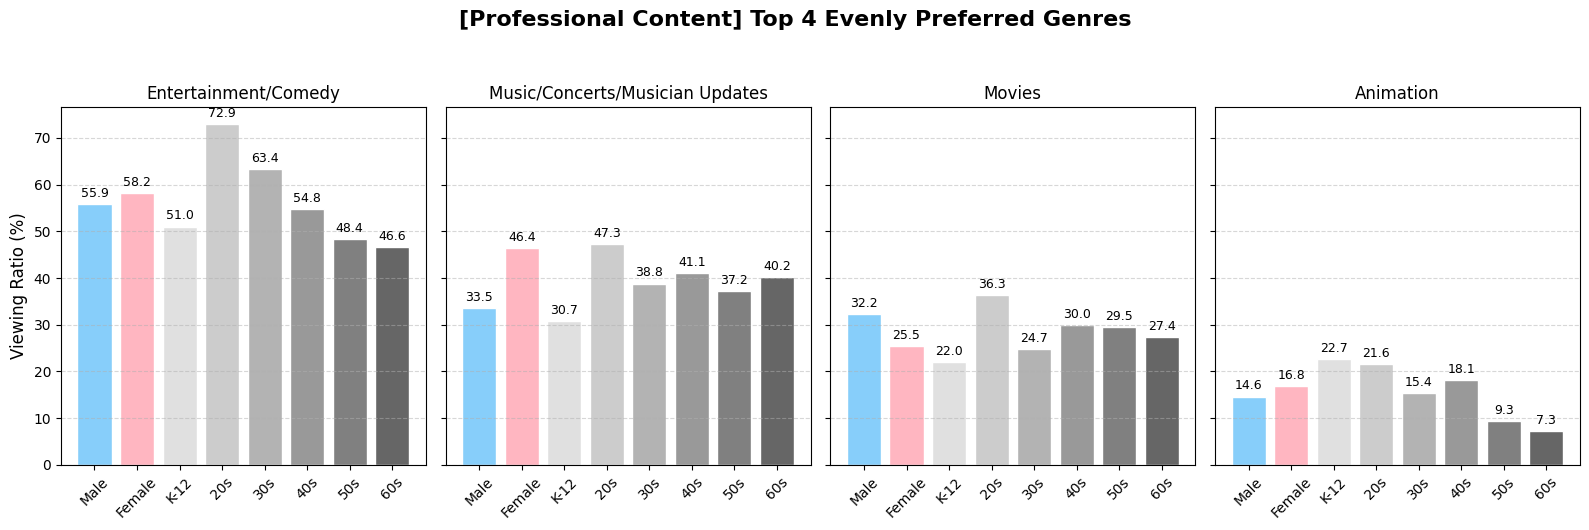

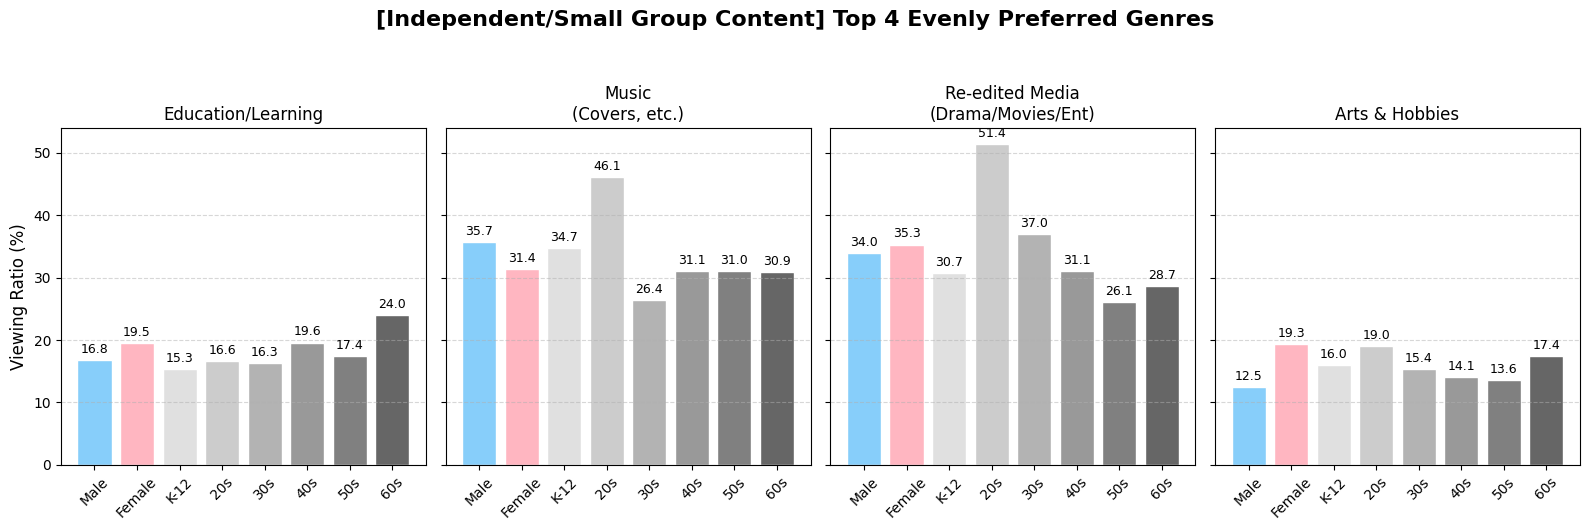

In [8]:
import matplotlib.pyplot as plt
import warnings

# 1. 폰트 설정을 matplotlib 기본 폰트(영어 전용)로 초기화
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = True # 마이너스 기호 깨짐 방지 해제 (영문 환경)

# 2. matplotlib의 폰트 찾기 관련 경고(Warning)를 무시하도록 설정
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
import matplotlib.pyplot as plt
import numpy as np

def plot_top4_demographic_clusters(categories, gender_data, age_data, title):
    # Create subplots for the 4 categories
    fig, axes = plt.subplots(1, len(categories), figsize=(4 * len(categories), 5), sharey=True)
    fig.suptitle(f'[{title}] Top 4 Evenly Preferred Genres', fontsize=16, fontweight='bold', y=1.05)

    # X-axis labels in English
    x_labels = ['Male', 'Female', 'K-12', '20s', '30s', '40s', '50s', '60s']

    # Colors: Blue (Male), Pink (Female), Grayscale (Ages)
    colors = ['#87CEFA', '#FFB6C1', '#E0E0E0', '#CCCCCC', '#B3B3B3', '#999999', '#808080', '#666666']

    for i, cat in enumerate(categories):
        ax = axes[i]

        # Merge gender and age data lists
        y_values = gender_data[cat] + age_data[cat]

        # Plot bar chart
        bars = ax.bar(x_labels, y_values, color=colors, edgecolor='white')

        # Wrap long category names for better display
        display_title = cat.replace(" (", "\n(") if "(" in cat else cat
        ax.set_title(display_title, fontsize=12)

        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        if i == 0:
            ax.set_ylabel('Viewing Ratio (%)', fontsize=12)

        # Annotate values on top of bars
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

# Automatically extract the Top 4 categories based on the calculated Total_Preference_Score
top4_pro_categories = pro_df.head(4).index.tolist()
top4_indie_categories = indie_df.head(4).index.tolist()

# Generate plots for both Professional and Independent content
plot_top4_demographic_clusters(top4_pro_categories, pro_gender_data, pro_age_data, "Professional Content")
plot_top4_demographic_clusters(top4_indie_categories, indie_gender_data, indie_age_data, "Independent/Small Group Content")